## Cube generation for `SCS4: EO enhanced benchmarking of GCB DGVMs` in the EO-LINCS project

### Scientific Case Study 4: EO enhanced benchmarking of GCB DGVMs

**Objective**: SCS4 aims to deepen the understanding of the processes that drive the European land carbon sink, with a focus on productivity, turnover, and the impacts of disturbances and land management. Leveraging new EO data and the International Land Model Benchmarking (ILAMB) system, it will assess Dynamic Global Vegetation Models (DGVMs) that contribute to the Global Carbon Budget (GCB) reports. The project will result in an enhanced ILAMB tool, offering insights into carbon dynamics and DGVM performance, and providing a roadmap for future model improvements.

**Outcomes**: An enhanced ILAMB evaluation tool with a focus on internal carbon dynamics and temporal 
change able to provide novel insights into DGVM capabilities to simulate the European land carbon sink and 
identify its main drivers. The spatiotemporal analysis will enable us to produce a roadmap for model 
improvements, in particular regarding forest management

-------------------------------------------------------------

The following notebook shows how the users can load data from various sources defined in `config.yml` using the `MultiSourceDataStore` tool.

#### **What You Can Do with This Notebook** 
- Load datasets from various sources as defined in the `config.yml`
- View the progress of each data request to the `MultiSourceDataStore`
- Quickly preview the datasets by plotting them.

#### **Requirements**  
Before proceeding, ensure you have the necessary dependencies installed (which is just one in this case!).
- `xcube-multistore`

It is available via conda-forge, and you can install it using
`conda install --channel conda-forge xcube-multistore`

Once you have it installed, you are ready to proceed.

This Multistore mainly works with a file called `config.yml` which is at the same file level as this notebook.
To understand what goes into the schema, you can read more [here](https://xcube-dev.github.io/xcube-multistore/).

-------------------------------------------------------

Let's import the `MultiSourceDataStore`

In [1]:
from xcube_multistore import MultiSourceDataStore

You can find out how to fill out the config file by also using this super helpful function `get_config_schema()`. Run it and try expand the fields to learn more about the possible properties that the `config.yml` accepts along with the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/).

In [2]:
MultiSourceDataStore.get_config_schema()

Now, we can initialize the `MultiSourceDataStore` by passing the path to the `config.yml` which currently is on the same level as this notebook.

By running the cell below, you would start seeing progress tables for each data that you requested in the `config.yml`.

**NOTE**: In the `config.yml` we are also using the `custom_processing` feature of this tool that allows us to run a function for processing each dataset separately. In this example, we have defined a module called `modify_dataset` that does some custom processing which takes a `xarray.Dataset` argument as input and returns a new `xarray.Dataset` object. To read more about this `custom_processing` function, you can see more [here](https://xcube-dev.github.io/xcube-multistore/config/#custom_processing).

In [9]:
msds = MultiSourceDataStore("config_Europe.yml")

Dataset identifier,Status,Message,Exception
biomass_xu_europe,COMPLETED,Dataset 'biomass_xu_europe' finished.,-
esa_cci_biomass_europe,COMPLETED,Dataset 'esa_cci_biomass_europe' finished.,-


We can now open the data using the xcube datastore framework API as usual. Note that the multi-source data store requires a data store called `storage`, which is configured in our `config.yml` under the `data_stores` section.

In [10]:
ds = msds.stores.storage.open_data("biomass_xu_europe.nc", chunks=dict(time=1))
ds

<xarray.Dataset> Size: 14MB
Dimensions:      (y: 304, x: 560)
Coordinates:
  * x            (x) float64 4kB -24.94 -24.81 -24.69 ... 44.69 44.81 44.94
  * y            (y) float64 2kB 72.94 72.81 72.69 72.56 ... 35.31 35.19 35.06
    spatial_ref  int64 8B ...
Data variables: (12/20)
    da_1         (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_2         (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_3         (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_4         (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_5         (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_6         (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    ...           ...
    da_15        (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_16        (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_17        (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_18        (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_19        (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
    da_20        (y, x) float32 681kB dask.array<chunksize=(304, 560), meta=np.ndarray>
Attributes:
    source:                     https://zenodo.org/records/4161694/files/test...
    geospatial_lon_units:       degrees_east
    geospatial_lon_min:         -25.299999999999972
    geospatial_lon_max:         45.20000000000003
    geospatial_lon_resolution:  0.1
    geospatial_lat_units:       degrees_north
    geospatial_lat_min:         34.89999999999999
    geospatial_lat_max:         73.39999999999999
    geospatial_lat_resolution:  0.1
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-25.299999999999972 34.8999999999999...
    date_modified:              2026-02-04T16:28:26.431951

We can now select a variable for one timestep and plot it for a quick preview of the data

In [11]:
ds.carbon_density.isel(time=1).plot()

AttributeError: 'Dataset' object has no attribute 'carbon_density'

In [6]:
ds = msds.stores.storage.open_data("esa_cci_biomass.nc", chunks=dict(time=1))
ds

<xarray.Dataset> Size: 415MB
Dimensions:      (time: 8, lat: 1800, lon: 3600)
Coordinates:
  * time         (time) datetime64[ns] 64B 2010-01-01 2015-01-01 ... 2021-01-01
  * lon          (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.8 179.9
  * lat          (lat) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
    spatial_ref  int64 8B ...
Data variables:
    agb          (time, lat, lon) float32 207MB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    agb_sd       (time, lat, lon) float32 207MB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
Attributes: (12/19)
    Conventions:                CF-1.7
    title:                      esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-p...
    date_created:               2025-08-05T08:10:13.608026
    processing_level:           L4
    time_coverage_start:        2010-01-01T00:00:00
    time_coverage_end:          2021-01-01T00:00:00
    ...                         ...
    geospatial_lat_min:         -89.9
    geospatial_lat_max:         90
    geospatial_lat_resolution:  0.1
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-180 -89.9, -180 90, 179.90000000000...
    date_modified:              2025-08-05T08:10:13.711161

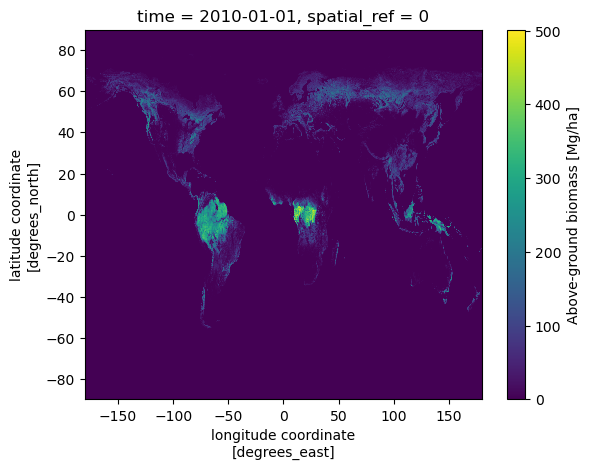

In [7]:
ds.agb.isel(time=0).plot()

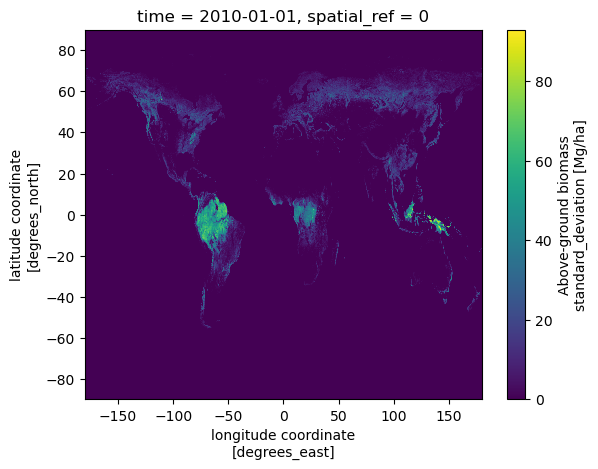

In [12]:
ds.agb_sd.isel(time=0).plot()